<a href="https://colab.research.google.com/github/webathonic/Women_in_Geospatial_mini_projects/blob/master/W%2BGLegacy_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install all required libraries
# (geopandas and its dependencies need special handling in Colab)
!pip install geopandas folium contextily requests pandas numpy scipy matplotlib --quiet

In [ ]:
import requests
import io
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.interpolate import griddata
from shapely.geometry import Point
import time
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# Download Nigeria state boundaries from geoBoundaries (free & open source)
print(" Downloading Nigeria state boundaries from geoBoundaries API...")

# Step 1: Ask the API for the download link
api_url = "https://www.geoboundaries.org/api/current/gbOpen/NGA/ADM1/"
response = requests.get(api_url, timeout=30)
geo_data = response.json()

# Step 2: Download the actual GeoJSON boundary file
geojson_url = geo_data['gjDownloadURL']
nigeria_states = gpd.read_file(geojson_url)

# Step 3: Create a single national boundary by dissolving all states together
nigeria_boundary = nigeria_states.dissolve()
nigeria_boundary_shape = nigeria_boundary.geometry.iloc[0]  # Single polygon for point checks

print(f" Downloaded successfully!")
print(f"   States/territories found: {len(nigeria_states)}")
print(f"   Columns in dataset: {list(nigeria_states.columns)}")

 Downloaded successfully!
   States/territories found: 37
   Columns in dataset: ['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType', 'geometry']


In [ ]:
print(nigeria_states.head())
print("crs", nigeria_states.crs)

                         shapeName shapeISO                  shapeID  \
0                      Cross River    NG-CR  27671186B81745654473385   
1  Abuja Federal Capital Territory    NG-FC  27671186B76269877687363   
2                             Ogun    NG-OG  27671186B83907961412659   
3                              Oyo    NG-OY  27671186B56513237316251   
4                           Sokoto    NG-SO  27671186B99510750195830   

  shapeGroup shapeType                                           geometry  
0        NGA      ADM1  POLYGON ((8.2743 4.85474, 8.29153 4.84805, 8.3...  
1        NGA      ADM1  POLYGON ((6.98081 8.44373, 6.98562 8.44342, 7....  
2        NGA      ADM1  POLYGON ((4.48324 6.32605, 4.48837 6.33622, 4....  
3        NGA      ADM1  POLYGON ((4.08836 7.13345, 4.08764 7.13805, 4....  
4        NGA      ADM1  POLYGON ((4.1264 13.24967, 4.17857 13.25407, 4...  
crs EPSG:4326


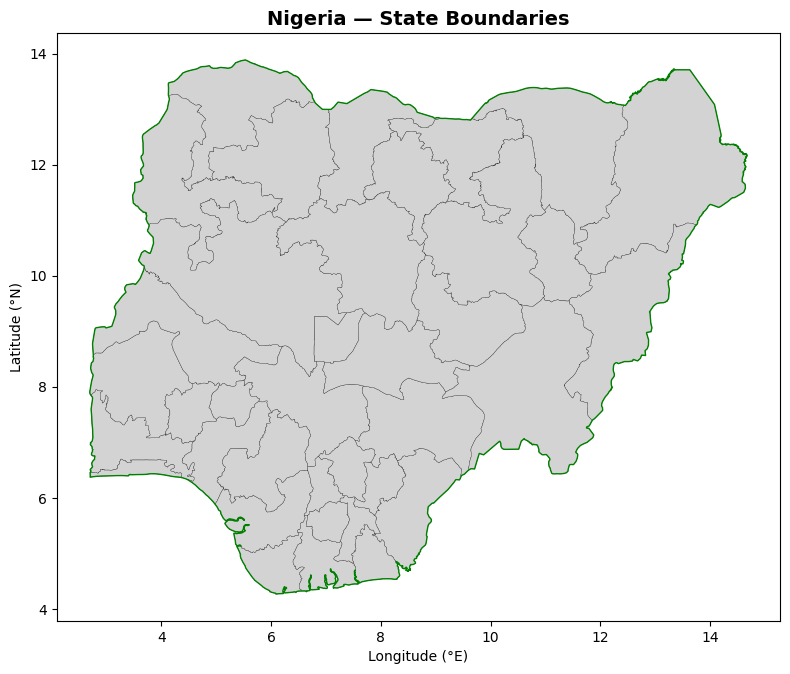

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Draw all state polygons with light grey fill
nigeria_states.plot(
    ax=ax,
    edgecolor='black',
    facecolor='lightgrey',
    linewidth=0.2
)

# Draw the national boundary as a thick outline
nigeria_boundary.boundary.plot(ax=ax, edgecolor='green', linewidth=1)

ax.set_title("Nigeria — State Boundaries", fontsize=14, fontweight='bold')
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
plt.tight_layout()
plt.savefig("nigeria_boundaries.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# SOURCE: UN OCHA / Nigeria National Population Commission
# DATASET: Nigeria Subnational Population Statistics (ADM1)
# YEAR: 2022 projection from 2006 National Census
# URL: https://data.humdata.org/dataset/cod-ps-nga
# DIRECT FILE: nga_admpop_adm1_2022.csv
# LICENCE: Creative Commons Attribution for Intergovernmental Organisations

POP_URL = (
    "https://data.humdata.org/dataset/a7c3de5e-ff27-4746-99cd-05f2ad9b1066"
    "/resource/d9fc551a-b5e4-4bed-9d0d-b047b6961817"
    "/download/nga_admpop_adm1_2022.csv"
)

print(" Downloading Nigeria state population data from UN OCHA / HDX...")
pop_response = requests.get(POP_URL, timeout=30)
pop_response.raise_for_status()

pop_raw = pd.read_csv(io.StringIO(pop_response.text))

print(f" Downloaded successfully!")
print(f"   Rows: {len(pop_raw)}")
print(f"   Columns: {list(pop_raw.columns)}")
print()
print("Raw preview:")
print(pop_raw[['ADM1_EN', 'T_TL']].head(10))


📥 Downloading Nigeria state population data from UN OCHA / HDX...
✅ Downloaded successfully!
   Rows: 37
   Columns: ['year', 'ISO3', 'ADM0_EN', 'ADM0_PCODE', 'ADM1_EN', 'ADM1_PCODE', 'F_TL', 'M_TL', 'T_TL', 'F_00_04', 'F_05_09', 'F_10_14', 'F_15_19', 'F_20_24', 'F_25_29', 'F_30_34', 'F_35_39', 'F_40_44', 'F_45_49', 'F_50_54', 'F_55_59', 'F_60_64', 'F_65_69', 'F_70_74', 'F_75_79', 'F_80Plus', 'M_00_04', 'M_05_09', 'M_10_14', 'M_15_19', 'M_20_24', 'M_25_29', 'M_30_34', 'M_35_39', 'M_40_44', 'M_45_49', 'M_50_54', 'M_55_59', 'M_60_64', 'M_65_69', 'M_70_74', 'M_75_79', 'M_80Plus', 'T_00_04', 'T_05_09', 'T_10_14', 'T_15_19', 'T_20_24', 'T_25_29', 'T_30_34', 'T_35_39', 'T_40_44', 'T_45_49', 'T_50_54', 'T_55_59', 'T_60_64', 'T_65_69', 'T_70_74', 'T_75_79', 'T_80Plus']

Raw preview:
       ADM1_EN     T_TL
0         Abia  4143093
1      Adamawa  4902055
2    Akwa Ibom  4979418
3      Anambra  5953517
4       Bauchi  8308783
5      Bayelsa  2537375
6        Benue  6141284
7        Borno  611146

In [ ]:
# ============================================================
# Extract only what we need:
#   ADM1_EN = State name (English)
#   T_TL    = Total population (all sexes, all ages)
# ============================================================

pop_df = pop_raw[['ADM1_EN', 'T_TL']].copy()
pop_df.columns = ['state', 'total_population']

# Convert raw population count to millions (for readability)
pop_df['population_millions'] = (pop_df['total_population'] / 1_000_000).round(3)

# Sort alphabetically
pop_df = pop_df.sort_values('state').reset_index(drop=True)

print(" Population data cleaned:")
print(f"   States: {len(pop_df)}")
print(f"   Total national population: {pop_df['total_population'].sum():,.0f}")
print(f"   ({pop_df['population_millions'].sum():.1f} million)")
print()
print(pop_df[['state', 'population_millions']].to_string(index=False))

# ── CITATION NOTE ──────────────────────────────────────────────
print("""
 CITATION:
   UN OCHA / Nigeria National Population Commission (2022).
   'Nigeria Subnational Population Statistics — Administrative Level 1.'
   Humanitarian Data Exchange (HDX). Dataset: cod-ps-nga.
   Projected from the 2006 Nigeria National Population Census.
   Available at: https://data.humdata.org/dataset/cod-ps-nga
""")

✅ Population data cleaned:
   States: 37
   Total national population: 216,798,930
   (216.8 million)

                    state  population_millions
                     Abia                4.143
                  Adamawa                4.902
                Akwa Ibom                4.979
                  Anambra                5.954
                   Bauchi                8.309
                  Bayelsa                2.537
                    Benue                6.141
                    Borno                6.111
              Cross River                4.406
                    Delta                5.636
                   Ebonyi                3.243
                      Edo                4.777
                    Ekiti                3.592
                    Enugu                4.690
Federal Capital Territory                3.067
                    Gombe                3.960
                      Imo                5.459
                   Jigawa                7.499
    

In [ ]:
# ============================================================
# SOURCE: The DHS Programme (USAID / ICF International)
# DATASET: Nigeria Demographic and Health Survey 2018
# SURVEY ID: NG2018DHS
# INDICATOR: HC_ELEC_H_ELC = % of households with electricity
# API DOCS: https://api.dhsprogram.com/
# NOTE: This API is free and public — no registration required
#       for aggregated indicator data.
#
# IMPORTANT: The Nigeria DHS reports electricity access at the
# GEOPOLITICAL ZONE level (6 zones), not individual state level.
# Each state is assigned to its official zone (see cell 3D).
# ============================================================

DHS_URL = (
    "https://api.dhsprogram.com/rest/dhs/data"
    "?countryIds=NG"
    "&indicatorIds=HC_ELEC_H_ELC"
    "&breakdown=subnational"
    "&surveyYear=2018"
    "&f=json"
)

print(" Fetching electricity access data from DHS API (Nigeria 2018 DHS)...")

dhs_response = requests.get(DHS_URL, timeout=30)
dhs_response.raise_for_status()

dhs_json = dhs_response.json()
dhs_raw = pd.DataFrame(dhs_json['Data'])

print(f" DHS API responded with {len(dhs_raw)} records")
print(f"   Available columns: {list(dhs_raw.columns)}")
print()
print("Raw DHS data preview:")
print(dhs_raw[['SurveyId', 'CharacteristicLabel', 'Indicator', 'Value']].to_string(index=False))

📥 Fetching electricity access data from DHS API (Nigeria 2018 DHS)...
✅ DHS API responded with 43 records
   Available columns: ['DataId', 'SurveyId', 'Indicator', 'IsPreferred', 'Value', 'SDRID', 'Precision', 'RegionId', 'SurveyYearLabel', 'SurveyType', 'SurveyYear', 'IndicatorOrder', 'DHS_CountryCode', 'CILow', 'CountryName', 'IndicatorType', 'CharacteristicId', 'CharacteristicCategory', 'IndicatorId', 'CharacteristicOrder', 'CharacteristicLabel', 'ByVariableLabel', 'DenominatorUnweighted', 'DenominatorWeighted', 'CIHigh', 'IsTotal', 'ByVariableId', 'LevelRank']

Raw DHS data preview:
 SurveyId CharacteristicLabel                   Indicator  Value
NG2018DHS       North Central Households with electricity   56.8
NG2018DHS         ..FCT Abuja Households with electricity   80.8
NG2018DHS             ..Benue Households with electricity   43.9
NG2018DHS              ..Kogi Households with electricity   59.8
NG2018DHS             ..Kwara Households with electricity   79.3
NG2018DHS       

In [ ]:
# The DHS CharacteristicLabel column will show Nigeria's
# 6 official geopolitical zones:
#   North Central, North East, North West,
#   South East, South South, South West
# We filter to these zone records (exclude the national total)
# then build a state-to-zone electricity access lookup.

# Filter: only zone-level records (exclude national "Total")
zone_elec = dhs_raw[
    dhs_raw['CharacteristicLabel'].isin([
        'North Central', 'North East', 'North West',
        'South East', 'South South', 'South West'
    ])
][['CharacteristicLabel', 'Value']].copy()

zone_elec.columns = ['zone', 'elec_access_pct']
zone_elec = zone_elec.reset_index(drop=True)

print(" Zone-level electricity access (% of households):")
print(zone_elec.to_string(index=False))


# OFFICIAL ZONE-TO-STATE MAPPING
# Source: Federal Republic of Nigeria — Official zonal divisions
# (established by the 1999 Constitution and INEC)

zone_to_states = {
    "North Central": [
        "Benue", "Federal Capital Territory", "Kogi",
        "Kwara", "Nasarawa", "Niger", "Plateau"
    ],
    "North East": [
        "Adamawa", "Bauchi", "Borno",
        "Gombe", "Taraba", "Yobe"
    ],
    "North West": [
        "Jigawa", "Kaduna", "Kano",
        "Katsina", "Kebbi", "Sokoto", "Zamfara"
    ],
    "South East": [
        "Abia", "Anambra", "Ebonyi", "Enugu", "Imo"
    ],
    "South South": [
        "Akwa Ibom", "Bayelsa", "Cross River",
        "Delta", "Edo", "Rivers"
    ],
    "South West": [
        "Ekiti", "Lagos", "Ogun", "Ondo", "Osun", "Oyo"
    ]
}

# Expand: create one row per state with its zone's electricity access rate
zone_elec_lookup = zone_elec.set_index('zone')['elec_access_pct'].to_dict()

state_elec_rows = []
for zone, states in zone_to_states.items():
    for state in states:
        state_elec_rows.append({
            'state': state,
            'zone': zone,
            'elec_access_pct': zone_elec_lookup.get(zone, None)
        })

elec_df = pd.DataFrame(state_elec_rows)

print(f"\n Electricity access mapped to {len(elec_df)} states")
print()
print(elec_df.to_string(index=False))

print("""
 CITATION:
   National Population Commission (NPC) Nigeria & ICF (2019).
   'Nigeria Demographic and Health Survey 2018.'
   Abuja, Nigeria / Rockville, MD: NPC and ICF.
   Indicator: HC_ELEC_H_ELC (Households with electricity).
   Accessed via DHS Programme open API: https://api.dhsprogram.com/
   Survey ID: NG2018DHS. Breakdown: Subnational (geopolitical zone).

 ZONE BOUNDARIES:
   Federal Republic of Nigeria (1999). Constitution of the Federal
   Republic of Nigeria 1999. Official zonal groupings of states.
""")

✅ Zone-level electricity access (% of households):
         zone  elec_access_pct
North Central             56.8
   North East             36.1
   North West             44.2
   South East             64.3
   South West             83.6
  South South             70.6

✅ Electricity access mapped to 37 states

                    state          zone  elec_access_pct
                    Benue North Central             56.8
Federal Capital Territory North Central             56.8
                     Kogi North Central             56.8
                    Kwara North Central             56.8
                 Nasarawa North Central             56.8
                    Niger North Central             56.8
                  Plateau North Central             56.8
                  Adamawa    North East             36.1
                   Bauchi    North East             36.1
                    Borno    North East             36.1
                    Gombe    North East             36.1
     

In [ ]:

# Align state names between the two datasets.
# HDX uses "Federal Capital Territory" — DHS zone mapping also uses this.
# If there are mismatches, fix them in the name_map dict below.


# Check for mismatches
pop_names  = set(pop_df['state'])
elec_names = set(elec_df['state'])

only_in_pop  = pop_names - elec_names
only_in_elec = elec_names - pop_names

if only_in_pop:
    print(f"  In population data but not electricity data: {only_in_pop}")
if only_in_elec:
    print(f"  In electricity data but not population data: {only_in_elec}")

# Add any name corrections here if needed:
name_map = {
    # "HDX name": "Electricity/zone name"
    # Example: "Nassarawa": "Nasarawa"
}

if name_map:
    pop_df['state'] = pop_df['state'].replace(name_map)

# Merge
df_states = pop_df.merge(elec_df, on='state', how='inner')

# Derive the access deficit
df_states['access_deficit_pct'] = 100 - df_states['elec_access_pct']
df_states['people_without_power_millions'] = (
    df_states['population_millions'] * df_states['access_deficit_pct'] / 100
).round(3)

print(f" Merged dataset: {len(df_states)} states")
print(f"\n   Total population:          {df_states['population_millions'].sum():.1f}M")
print(f"   People without electricity: {df_states['people_without_power_millions'].sum():.1f}M")

print(f"\n   Top 10 states by unserved population:")
print(
    df_states.sort_values('people_without_power_millions', ascending=False)
    [['state', 'zone', 'population_millions', 'elec_access_pct', 'people_without_power_millions']]
    .head(10)
    .to_string(index=False)
)

 Merged dataset: 37 states

   Total population:          216.8M
   People without electricity: 90.6M

   Top 10 states by unserved population:
                    state          zone  population_millions  elec_access_pct  people_without_power_millions
                     Kano    North West               15.462             44.2                          8.628
                  Katsina    North West               10.368             44.2                          5.785
                   Bauchi    North East                8.309             36.1                          5.309
                   Kaduna    North West                9.032             44.2                          5.040
                   Jigawa    North West                7.499             44.2                          4.184
                    Borno    North East                6.111             36.1                          3.905
                   Sokoto    North West                6.391             44.2                

Total grid points in bounding box: 1428
Grid points inside Nigeria after clipping: 837


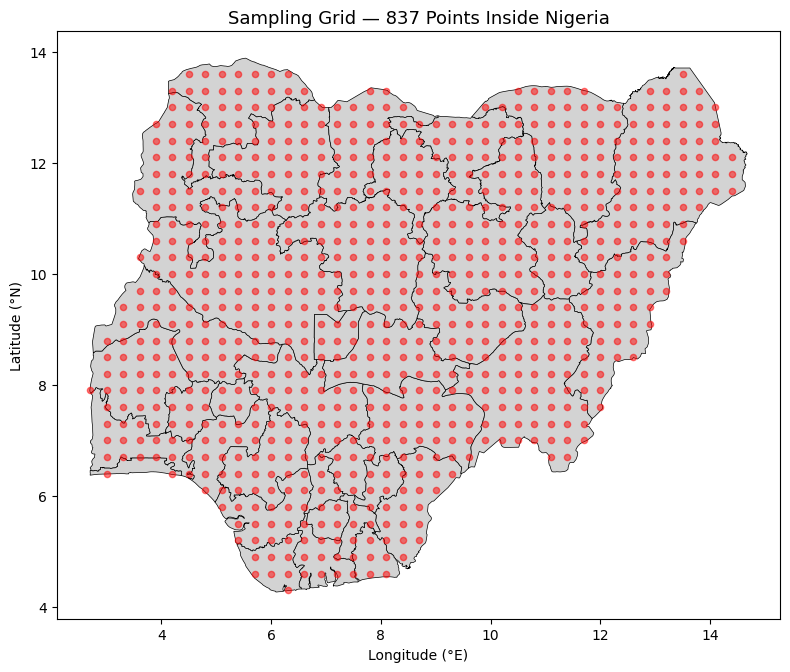

In [ ]:
# Nigeria's approximate bounding box (the rectangle that contains Nigeria)
min_lon, max_lon = 2.7, 15.0   # East-West extent
min_lat, max_lat = 4.0, 14.0   # North-South extent

# Grid spacing in degrees (1.0° ≈ 111km)
# Use 1.0 for speed (≈45 points), or 0.5 for more detail (≈120 points)
grid_spacing = 0.3

# Generate a regular grid of latitude/longitude coordinates
lons = np.arange(min_lon, max_lon, grid_spacing)
lats = np.arange(min_lat, max_lat, grid_spacing)

# Create every lat/lon combination in the grid
all_grid_points = [(lat, lon) for lat in lats for lon in lons]
print(f"Total grid points in bounding box: {len(all_grid_points)}")

# Convert to a GeoDataFrame (each point becomes a geometry object)
grid_gdf = gpd.GeoDataFrame(
    {
        'lat': [p[0] for p in all_grid_points],
        'lon': [p[1] for p in all_grid_points]
    },
    geometry=[Point(p[1], p[0]) for p in all_grid_points],
    crs="EPSG:4326"
)

# Remove points that fall outside Nigeria (ocean, neighbouring countries)
grid_gdf = grid_gdf[
    grid_gdf.geometry.within(nigeria_boundary_shape)
].reset_index(drop=True)

print(f"Grid points inside Nigeria after clipping: {len(grid_gdf)}")

# Preview the grid
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
nigeria_states.plot(
    ax=ax,
    edgecolor='black',
    facecolor='lightgrey',
    linewidth=0.5
)
grid_gdf.plot(ax=ax, color='red', markersize=20, alpha=0.5, zorder=5)
ax.set_title(f"Sampling Grid — {len(grid_gdf)} Points Inside Nigeria", fontsize=13)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
plt.tight_layout()
plt.show()

In [ ]:
def fetch_solar_irradiance(lat, lon, retries=3):
    """
    Queries NASA POWER API for annual average solar irradiance at a given coordinate.

    Parameters
    ----------
    lat : float — Latitude of the point
    lon : float — Longitude of the point
    retries : int — Number of retry attempts if the request fails

    Returns
    -------
    float — Annual average irradiance in kWh/m²/day, or None if request fails
    """
    url = "https://power.larc.nasa.gov/api/temporal/climatology/point"

    params = {
        "parameters": "ALLSKY_SFC_SW_DWN",  # Solar irradiance parameter
        "community": "RE",                   # Renewable Energy community dataset
        "longitude": round(lon, 4),
        "latitude": round(lat, 4),
        "format": "JSON"
    }

    for attempt in range(retries):
        try:
            response = requests.get(url, params=params, timeout=30)
            if response.status_code == 200:
                data = response.json()
                # 'ANN' = annual average (as opposed to monthly values like 'JAN', 'FEB'...)
                annual_avg = data['properties']['parameter']['ALLSKY_SFC_SW_DWN']['ANN']
                return annual_avg
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(2)  # Wait before retrying
    return None  # Return None if all attempts fail


# ---- Main fetching loop ----
print(" Fetching solar irradiance data from NASA POWER API...")
print(f"   Querying {len(grid_gdf)} grid points. Please be patient...\n")

solar_values = []

for i, row in grid_gdf.iterrows():
    value = fetch_solar_irradiance(row['lat'], row['lon'])
    solar_values.append(value)

    status = f"{value:.2f} kWh/m²/day" if value is not None else " FAILED"
    print(f"  [{i+1:02d}/{len(grid_gdf)}] Lat: {row['lat']:.1f}°, Lon: {row['lon']:.1f}° → {status}")

    time.sleep(0.4)  # Small delay to avoid overwhelming the API

# Attach solar values to our grid GeoDataFrame
grid_gdf['solar_kwh'] = solar_values

# Remove any points that failed
failed_count = grid_gdf['solar_kwh'].isna().sum()
grid_gdf = grid_gdf.dropna(subset=['solar_kwh']).reset_index(drop=True)

print(f"\n{'='*50}")
print(f" Successfully fetched: {len(grid_gdf)} points")
if failed_count > 0:
    print(f"  Failed (will be interpolated): {failed_count} points")

print(f"\n Solar Irradiance Summary:")
print(f"   Minimum:  {grid_gdf['solar_kwh'].min():.3f} kWh/m²/day")
print(f"   Maximum:  {grid_gdf['solar_kwh'].max():.3f} kWh/m²/day")
print(f"   Average:  {grid_gdf['solar_kwh'].mean():.3f} kWh/m²/day")
print(f"   Std Dev:  {grid_gdf['solar_kwh'].std():.3f} kWh/m²/day")

 Fetching solar irradiance data from NASA POWER API...
   Querying 837 grid points. Please be patient...

  [01/837] Lat: 4.3°, Lon: 6.3° → 4.19 kWh/m²/day
  [02/837] Lat: 4.6°, Lon: 5.7° → 4.25 kWh/m²/day
  [03/837] Lat: 4.6°, Lon: 6.0° → 4.19 kWh/m²/day
  [04/837] Lat: 4.6°, Lon: 6.3° → 4.19 kWh/m²/day
  [05/837] Lat: 4.6°, Lon: 6.6° → 4.19 kWh/m²/day
  [06/837] Lat: 4.6°, Lon: 6.9° → 4.19 kWh/m²/day
  [07/837] Lat: 4.6°, Lon: 7.2° → 4.12 kWh/m²/day
  [08/837] Lat: 4.6°, Lon: 7.5° → 4.12 kWh/m²/day
  [09/837] Lat: 4.6°, Lon: 7.8° → 4.12 kWh/m²/day
  [10/837] Lat: 4.6°, Lon: 8.1° → 4.19 kWh/m²/day
  [11/837] Lat: 4.9°, Lon: 5.7° → 4.25 kWh/m²/day
  [12/837] Lat: 4.9°, Lon: 6.0° → 4.19 kWh/m²/day
  [13/837] Lat: 4.9°, Lon: 6.3° → 4.19 kWh/m²/day
  [14/837] Lat: 4.9°, Lon: 6.6° → 4.19 kWh/m²/day
  [15/837] Lat: 4.9°, Lon: 6.9° → 4.19 kWh/m²/day
  [16/837] Lat: 4.9°, Lon: 7.2° → 4.12 kWh/m²/day
  [17/837] Lat: 4.9°, Lon: 7.5° → 4.12 kWh/m²/day
  [18/837] Lat: 4.9°, Lon: 7.8° → 4.12 kWh/m

In [ ]:
# Interpolation fills the gaps between our sample points
# to create a smooth continuous surface across all of Nigeria.
# This is the same principle used in GIS for kriging and IDW.

print(" Interpolating solar values across Nigeria...")

# Fine grid for the interpolated output (higher resolution than our samples)
interp_spacing = 0.08  # degrees (finer = smoother map, but slower)
xi = np.arange(min_lon, max_lon, interp_spacing)
yi = np.arange(min_lat, max_lat, interp_spacing)
xi_grid, yi_grid = np.meshgrid(xi, yi)

# Perform cubic interpolation using our sample points as control points
points = np.array(list(zip(grid_gdf['lon'], grid_gdf['lat'])))
values = grid_gdf['solar_kwh'].values

zi = griddata(points, values, (xi_grid, yi_grid), method='cubic')


# Apply mask — cells outside Nigeria become NaN (transparent on the map)
zi_masked = np.where(mask, zi, np.nan)

# Clip any extreme interpolation artifacts at the edges
vmin = grid_gdf['solar_kwh'].min() - 0.3
vmax = grid_gdf['solar_kwh'].max() + 0.3
zi_masked = np.clip(zi_masked, vmin, vmax)
zi_masked = np.where(mask, zi_masked, np.nan)

print(f" Interpolation complete!")
print(f"   Output grid size: {zi_masked.shape[0]} rows × {zi_masked.shape[1]} columns")
print(f"   Valid cells (inside Nigeria): {np.sum(~np.isnan(zi_masked)):,}")

 Interpolating solar values across Nigeria...
 Interpolation complete!
   Output grid size: 125 rows × 154 columns
   Valid cells (inside Nigeria): 11,512


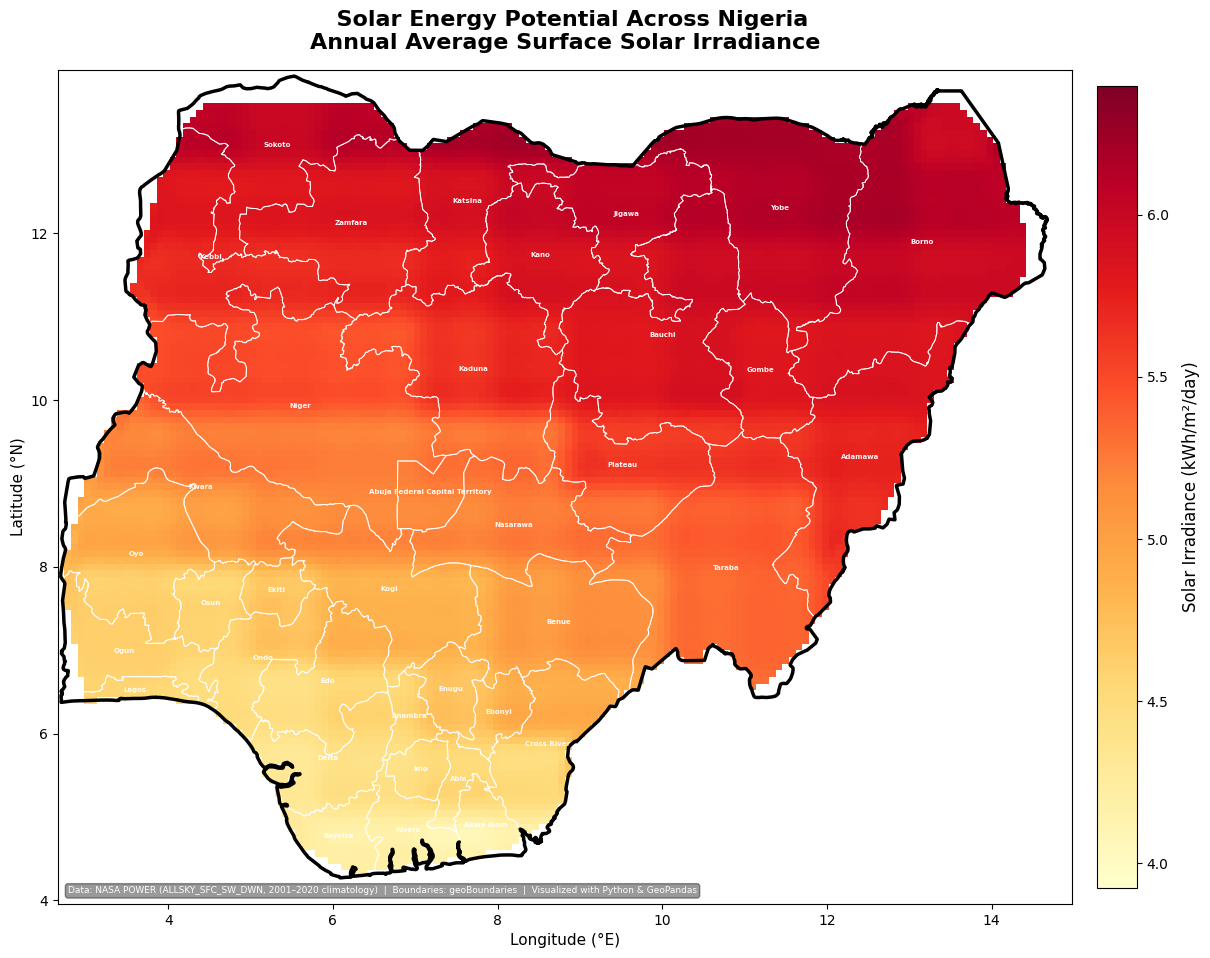

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(13, 11))

# Solar-themed colour palette: pale yellow → orange → deep red
cmap = plt.cm.YlOrRd

# Plot the interpolated surface as a colour mesh
img = ax.pcolormesh(
    xi_grid, yi_grid, zi_masked,
    cmap=cmap,
    shading='auto',
    vmin=grid_gdf['solar_kwh'].min() - 0.2,
    vmax=grid_gdf['solar_kwh'].max() + 0.2
)

# Overlay state boundary lines in white
nigeria_states.boundary.plot(
    ax=ax, linewidth=0.7, edgecolor='white', alpha=0.9
)

# Draw national boundary as a thick black outline
nigeria_boundary.boundary.plot(ax=ax, linewidth=2.5, edgecolor='black')

# Add state name labels
for idx, row in nigeria_states.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        row['shapeName'],
        xy=(centroid.x, centroid.y),
        fontsize=5,
        ha='center',
        va='center',
        color='white',
        fontweight='bold',
        alpha=0.95
    )

# Colorbar (legend)
cbar = plt.colorbar(img, ax=ax, orientation='vertical', pad=0.02, shrink=0.75)
cbar.set_label('Solar Irradiance (kWh/m²/day)', fontsize=12, labelpad=10)
cbar.ax.tick_params(labelsize=10)

# Add threshold tick marks on colorbar
for threshold, label in [(4.5, 'Low'), (5.5, 'High'), (6.5, 'Very High')]:
    if grid_gdf['solar_kwh'].min() < threshold < grid_gdf['solar_kwh'].max():
        cbar.ax.axhline(
            y=(threshold - (grid_gdf['solar_kwh'].min() - 0.2)) /
              ((grid_gdf['solar_kwh'].max() + 0.2) - (grid_gdf['solar_kwh'].min() - 0.2)),
            color='black', linewidth=1.5, linestyle='--', alpha=0.6
        )

# Titles and labels
ax.set_title(
    "  Solar Energy Potential Across Nigeria\nAnnual Average Surface Solar Irradiance",
    fontsize=16, fontweight='bold', pad=15
)
ax.set_xlabel("Longitude (°E)", fontsize=11)
ax.set_ylabel("Latitude (°N)", fontsize=11)

# Data source credit
ax.text(
    0.01, 0.01,
    "Data: NASA POWER (ALLSKY_SFC_SW_DWN, 2001–2020 climatology)  |  "
    "Boundaries: geoBoundaries  |  Visualized with Python & GeoPandas",
    transform=ax.transAxes, fontsize=6.5, color='white', va='bottom',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.4)
)

plt.tight_layout()
plt.savefig("nigeria_solar_heatmap.png", dpi=200, bbox_inches='tight')
plt.show()


In [ ]:
# Assign each sample point to the state it falls inside,
# then calculate statistics per state.

print(" Calculating solar statistics per state...")

# Spatial join: each sample point is matched to the state containing it
points_in_states = gpd.sjoin(
    grid_gdf[['lat', 'lon', 'solar_kwh', 'geometry']],
    nigeria_states[['shapeName', 'geometry']],
    how='left',
    predicate='within'
)

# Group by state name and compute summary statistics
state_solar = (
    points_in_states
    .groupby('shapeName')['solar_kwh']
    .agg(
        avg_solar='mean',
        min_solar='min',
        max_solar='max',
        sample_points='count'
    )
    .reset_index()
    .sort_values('avg_solar', ascending=False)
    .reset_index(drop=True)
)

# Add rank column
state_solar.insert(0, 'rank', range(1, len(state_solar) + 1))

print("\n TOP 10 STATES — Highest Solar Potential")
print("-" * 55)
print(state_solar.head(10).to_string(index=False))

print("\n BOTTOM 5 STATES — Lowest Solar Potential")
print("-" * 55)
print(state_solar.tail(5).to_string(index=False))

print(f"\n States with data: {len(state_solar)} out of {len(nigeria_states)}")

# Note: States with 0 sample points (very small ones like Lagos)
# may not appear — this is expected with a 1° grid
missing = set(nigeria_states['shapeName']) - set(state_solar['shapeName'])
if missing:
    print(f"  States with no sample points (too small for 1° grid): {missing}")
    print("   These will appear grey on the choropleth map.")
    print("   Tip: Reduce grid_spacing to 0.5 in Cell 5 to capture them.")

 Calculating solar statistics per state...

 TOP 10 STATES — Highest Solar Potential
-------------------------------------------------------
 rank shapeName  avg_solar  min_solar  max_solar  sample_points
    1      Yobe   6.104607     5.8272     6.1980             41
    2    Jigawa   6.022414     5.8642     6.1963             22
    3     Borno   6.012894     5.8272     6.1867             66
    4    Sokoto   5.973227     5.6993     6.0938             30
    5   Katsina   5.942408     5.6947     6.1954             25
    6      Kano   5.889967     5.7149     5.9986             18
    7    Bauchi   5.851833     5.5879     6.1044             48
    8     Gombe   5.810769     5.6388     5.9717             16
    9   Zamfara   5.806306     5.6726     6.0938             31
   10     Kebbi   5.732397     5.5193     6.0727             31

 BOTTOM 5 STATES — Lowest Solar Potential
-------------------------------------------------------
 rank shapeName  avg_solar  min_solar  max_solar  sample

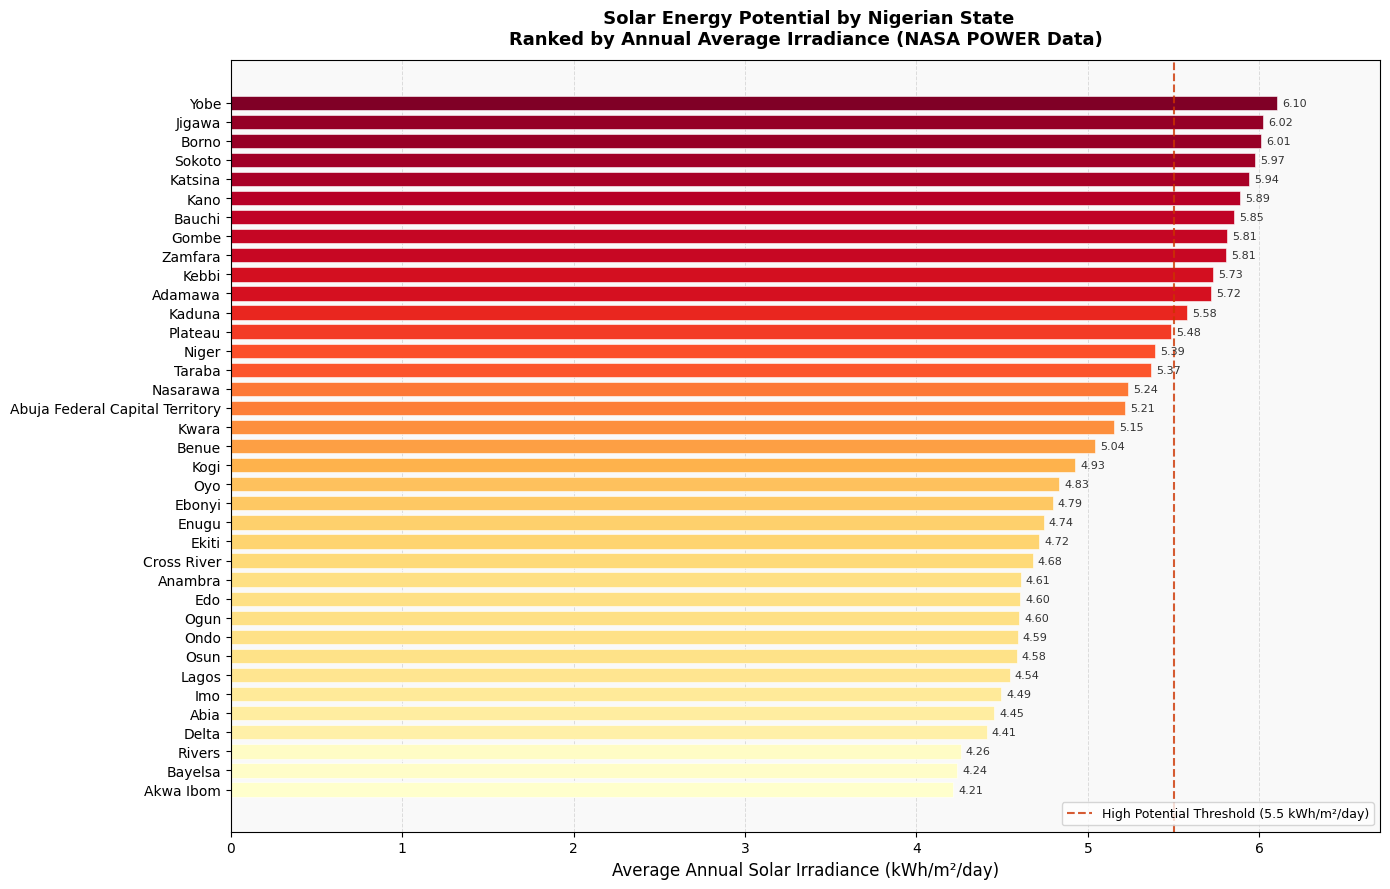

In [ ]:
fig, ax = plt.subplots(figsize=(14, 9))

# Normalize solar values to 0–1 range for colourmap
norm_vals = (state_solar['avg_solar'] - state_solar['avg_solar'].min()) / \
            (state_solar['avg_solar'].max() - state_solar['avg_solar'].min())
colors = plt.cm.YlOrRd(norm_vals)

# Draw horizontal bars
bars = ax.barh(
    state_solar['shapeName'],
    state_solar['avg_solar'],
    color=colors,
    edgecolor='white',
    linewidth=0.4,
    height=0.75
)

# Add value labels at end of each bar
for bar, val in zip(bars, state_solar['avg_solar']):
    ax.text(
        bar.get_width() + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center', ha='left', fontsize=8, color='#333333'
    )

# Add a vertical line marking "high potential" threshold
if state_solar['avg_solar'].min() < 5.5 < state_solar['avg_solar'].max():
    ax.axvline(
        x=5.5, color='#CC3300', linestyle='--',
        linewidth=1.5, alpha=0.8,
        label='High Potential Threshold (5.5 kWh/m²/day)'
    )
    ax.legend(fontsize=9, loc='lower right')

# Formatting
ax.set_xlabel("Average Annual Solar Irradiance (kWh/m²/day)", fontsize=12)
ax.set_title(
    " Solar Energy Potential by Nigerian State\n"
    "Ranked by Annual Average Irradiance (NASA POWER Data)",
    fontsize=13, fontweight='bold', pad=12
)
ax.invert_yaxis()  # Highest at the top
ax.set_xlim(0, state_solar['avg_solar'].max() + 0.6)
ax.grid(axis='x', linestyle='--', alpha=0.4, linewidth=0.7)
ax.set_axisbelow(True)

# Background
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('white')

plt.tight_layout()
#plt.savefig("nigeria_solar_by_state_chart.png", dpi=150, bbox_inches='tight')
plt.show()


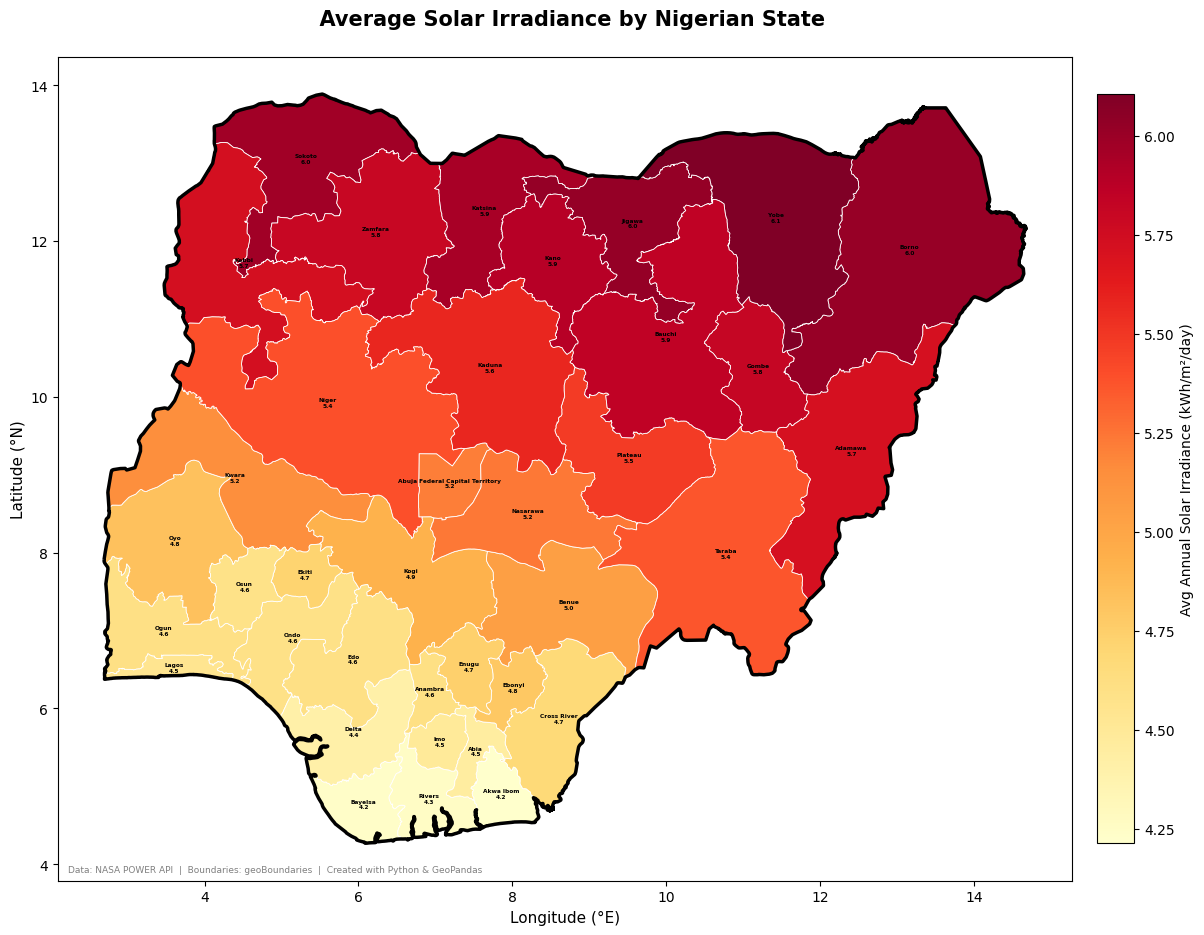

 Choropleth saved as 'nigeria_solar_choropleth.png'


In [ ]:
# Merge the solar statistics back into the state geodataframe
nigeria_solar_map = nigeria_states.merge(
    state_solar[['shapeName', 'avg_solar']],
    on='shapeName',
    how='left'
)

fig, ax = plt.subplots(1, 1, figsize=(13, 11))

# Draw the choropleth
nigeria_solar_map.plot(
    column='avg_solar',
    cmap='YlOrRd',
    linewidth=0.6,
    edgecolor='white',
    legend=True,
    legend_kwds={
        'label': 'Avg Annual Solar Irradiance (kWh/m²/day)',
        'orientation': 'vertical',
        'shrink': 0.7,
        'pad': 0.02
    },
    ax=ax,
    missing_kwds={
        'color': 'lightgray',
        'label': 'Insufficient sample points'
    }
)

# National boundary
nigeria_boundary.boundary.plot(ax=ax, linewidth=2.5, edgecolor='black')

# State labels with solar values
for idx, row in nigeria_solar_map.iterrows():
    centroid = row.geometry.centroid
    name = row['shapeName']
    val = row['avg_solar']

    label = f"{name}\n{val:.1f}" if not pd.isna(val) else name

    ax.annotate(
        label,
        xy=(centroid.x, centroid.y),
        fontsize=4.2,
        ha='center',
        va='center',
        color='black',
        fontweight='bold'
    )

ax.set_title(
    "  Average Solar Irradiance by Nigerian State\n",
    fontsize=15, fontweight='bold'
)
ax.set_xlabel("Longitude (°E)", fontsize=11)
ax.set_ylabel("Latitude (°N)", fontsize=11)
ax.text(
    0.01, 0.01,
    "Data: NASA POWER API  |  Boundaries: geoBoundaries  |  "
    "Created with Python & GeoPandas",
    transform=ax.transAxes, fontsize=6.5, color='gray'
)

plt.tight_layout()
plt.savefig("nigeria_solar_choropleth.png", dpi=200, bbox_inches='tight')
plt.show()


In [ ]:
# Merge solar data with our state data dict
master_df = df_states.merge(
    nigeria_states,
    on='state_shapefile',
    how='left'
)

# How many states have solar data?
missing_solar = master_df['avg_solar'].isna().sum()
if missing_solar > 0:
    print(f"⚠️  {missing_solar} states have no solar sample points (too small for 1° grid)")
    print(f"   Affected: {master_df[master_df['avg_solar'].isna()]['state'].tolist()}")
    print("   Filling with nearest neighbour estimate from interpolation (next cell)...")
    # Fill missing solar values with Nigeria average as fallback
    nigeria_avg_solar = master_df['avg_solar'].mean()
    master_df['avg_solar'] = master_df['avg_solar'].fillna(nigeria_avg_solar)

print("\n✅ Master dataset assembled:")
print(master_df[['state', 'population_millions', 'elec_access_pct',
                  'access_deficit_pct', 'people_without_power_millions',
                  'avg_solar']].sort_values('people_without_power_millions',
                  ascending=False).head(10).to_string(index=False))

NameError: name 'nigeria_states' is not defined